# 6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None
SIMPLE  =                    T /FITS header                                     BITPIX  =                   16 /No.Bits per pixel                               NAXIS   =                    2 /No.dimensions                                   NAXIS1  =                  530 /Length X axis                                   NAXIS2  =                  530 /Length Y axis                                   END                                                                                                                                                                                                                                                                                                                                                                           

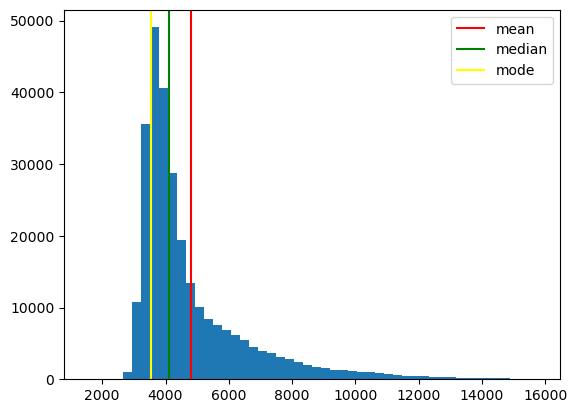

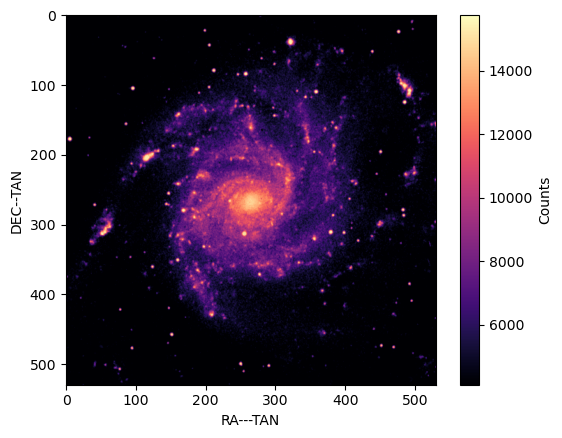

In [15]:
import numpy as np
from astropy.io import fits
from scipy import stats
import matplotlib.pyplot as plt

fit = fits.open("m101.fits")
print(fit.info())
"""
2 HDU's
the primairy contains the data
numbertype is int 16, so 16 bit integers
"""
print(fit[0].header[0:5]) #BITPIX = 16
dat = fit[0].data
print(np.shape(dat)) #does correspond, also 530 x 530, also with NAXIS1,2
print(f"dtype: {dat.dtype}") #"dtype >i2 represents a big-endian 16-bit signed intege", so yes, it is the same
datflat = dat.flat
print(f"max:{np.max(datflat)}, min:{np.min(datflat)}, mean: {np.mean(datflat)}, std: {np.std(datflat)}, med: {np.median(datflat)}, mode: {stats.mode(datflat)[0]}")

fig, ax = plt.subplots()
ax.axvline(np.mean(datflat),color = "r",label ="mean")
ax.axvline(np.median(datflat),color = "g", label = "median")
ax.axvline(stats.mode(datflat)[0],color = "yellow", label = "mode")
ax.hist(datflat, bins = 50, )
plt.legend()
plt.show()

datarray = np.asarray(dat)
med = np.median(datarray)
label_x = fit[0].header['CTYPE1']
label_y = fit[0].header['CTYPE2']

im = plt.imshow(datarray, vmin = med, cmap='magma')
plt.xlabel(label_x)
plt.ylabel(label_y)
cbar = plt.colorbar(im)
cbar.set_label('Counts')
plt.show()

fit[0].header['BUNIT'] = 'Counts'
fit[0].data = datarray
fit.writeto('m101_float.fits', overwrite=True, output_verify='ignore')

# 6.3

In [2]:
import numpy as np
from astropy.io import fits

fit = fits.open("m101.fits")
print(fit.info())

dat = fit[0].data
sq = np.s_[499:519,499:519]

x = dat[sq]
y = x.flatten()
block = y.astype(np.float64)

xrms = np.sqrt(1/len(block) * np.sum(block**2))#np.sqrt(np.mean(np.sum(block**2)))#

print(f"xrms = {xrms}, with mean: {np.mean(block)} and std: {np.std(block)}")
#why does std differ form xrms?

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None
xrms = 4044.6952252302026, with mean: 4004.23 and std: 570.7027002739693


In [13]:
import numpy as np
from astropy.io import fits
from scipy import stats

fit = fits.open("m101.fits")
print(fit.info())

dat = fit[0].data
np.shape(dat)
flatdatf = dat.flatten().astype(np.float64)
flatdat = dat.flatten()
print(np.sqrt(1/len(flatdatf) * np.sum(flatdatf**2)))

varf = stats.describe(flatdatf)[3]
print(np.sqrt(varf))
var = stats.describe(flatdat)[3]
print(np.sqrt(var))
print(np.sqrt(1/len(flatdat) * np.sum(flatdat**2)))
print(stats.describe(flatdatf))



Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None
5139.740002510873
1848.2558984219054
1848.2558984219054
6.644608785827525
DescribeResult(nobs=np.int64(280900), minmax=(np.float64(1507.0), np.float64(15752.0)), mean=np.float64(4795.924268422927), variance=np.float64(3416049.866051364), skewness=np.float64(2.1344311442506227), kurtosis=np.float64(5.202208842285202))


# 6.5

In [8]:
import numpy as np
from astropy.io import fits
nm0 = fits.open("noisemap0.fits")[0].data
nm1 = fits.open("noisemap1.fits")[0].data
nm2 = fits.open("noisemap2.fits")[0].data
print("nm0:", np.std(nm0),"nm1:", np.std(nm1),"nm2:", np.std(nm2))

nmtot = np.stack([nm0,nm1,nm2], axis = 0)

mean_image = np.mean(nmtot, axis=0)

std_mean_image = np.std(mean_image)
print(f"Standard deviation of mean image: {std_mean_image}")

sigma0 = np.std(nm0)
sigma1 = np.std(nm1)
sigma2 = np.std(nm2)
N = 3

theoretical_std = (1/N) * np.sqrt(sigma0**2 + sigma1**2 + sigma2**2)
print(f"Theoretical standard deviation: {theoretical_std}")

# compare
diff = abs(std_mean_image - theoretical_std)
print(f"Difference: {diff}")


nm0: 9.98401556679484 nm1: 10.003955116338458 nm2: 9.995349488722516
Standard deviation of mean image: 5.773191380233297
Theoretical standard deviation: 5.770294583366139
Difference: 0.002896796867157825


# 6.6

In [39]:
import numpy as np
from astropy.io import fits
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

t = Table(data)

mask = (
    (t['STARFLAG'] == 0) & 
    (t['ASPCAPFLAG'] == 0) & 
    (t['SNR'] > 10) & 
    (t['GAIAEDR3_PARALLAX'] / t['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(t['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

t['DATAFLAG'] = 0
t['DATAFLAG'][mask] = 1

m_G = t['GAIAEDR3_PHOT_G_MEAN_MAG']
px = t['GAIAEDR3_PARALLAX']

valid_px = px > 0
abs_mag = np.full(len(px), -1.0)
abs_mag[valid_px] = m_G[valid_px] - 5 * np.log10(px[valid_px]/1000) + 5

t['ABSOLUTE_MAG'] = np.where(t['DATAFLAG'] == 1, abs_mag, -1.0)

t.write('APOGEE_update.fits', format = 'fits', overwrite = True)

print(t['ABSOLUTE_MAG'])
print(t['DATAFLAG'])


   ABSOLUTE_MAG   
------------------
              -1.0
              -1.0
              -1.0
              -1.0
31.653636932373047
              -1.0
               ...
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
Length = 733901 rows
DATAFLAG
--------
       0
       0
       0
       0
       1
       0
     ...
       0
       0
       0
       0
       0
       0
       0
Length = 733901 rows


# 6.7 from here

0        1.779496e+06
1        1.558734e+06
2        9.203894e+05
3        8.074825e+05
4        1.122358e+06
             ...     
32195    3.396710e+02
32196    3.696483e+01
32197    3.764135e+02
32198    1.515553e+02
32199    1.482101e+03
Name: phot_g_mean_flux, Length: 32200, dtype: float64
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


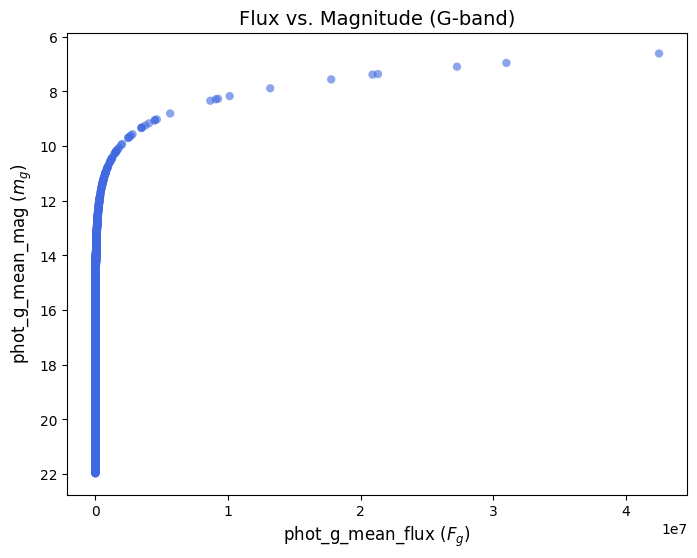

Value for m0: 25.68840037029544


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = pd.read_csv("gaiaTestData.csv")

condition = t["phot_g_mean_flux"] == t["phot_g_mean_flux"].max()
print(t["phot_g_mean_flux"])
print(t[condition])
t.sort_values(by=["phot_g_mean_flux"], ascending=True)
                 
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(t['phot_g_mean_flux'], t['phot_g_mean_mag'], color='royalblue', alpha=0.6, edgecolors='none')

ax.set_title('Flux vs. Magnitude (G-band)', fontsize=14)
ax.set_xlabel('phot_g_mean_flux ($F_g$)', fontsize=12)
ax.set_ylabel('phot_g_mean_mag ($m_g$)', fontsize=12)
ax.invert_yaxis()
plt.show()

mg = t["phot_g_mean_mag"]
F_g = t["phot_g_mean_flux"]

m0 = mg+2.5* np.log10(F_g)
print(f"Value for m0: {m0.mean()}")

In [3]:
from astroquery.gaia import Gaia
import pandas as pd
query = """ 
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error >5
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""
job = Gaia.launch_job(query)
t = job.get_results()
tp = t.to_pandas()
print(t)

t.write("astroquery_gaia.fits", format = 'fits', overwrite = True)

     source_id              ra         ... phot_bp_mean_mag phot_rp_mean_mag
                           deg         ...       mag              mag       
------------------- ------------------ ... ---------------- ----------------
4267180339403392768  286.7169128963743 ...        15.942071        14.419943
6709252873623174016     276.6911939192 ...        16.380306        15.151749
4040949706019490560 265.22936348434496 ...        16.118845        13.680644
4517539583701880064 284.02566215626837 ...        16.652264        15.347014
1823532754729083392 300.80580445460237 ...        14.782262        13.795675
3586362911238437248 171.80987737943448 ...        14.809981        12.990531
2220802729771409024  320.3998716199124 ...        17.259604        15.978823
5850180760683762688  205.6911379853152 ...         18.26916        17.014418
2128624652762622080  294.2962728879645 ...        19.113455        17.192604
                ...                ... ...              ...              ...

# 6.14

In [112]:
import numpy as np

class fib:
    def __init__(self, maximum, devid, final):
        self.maximum = maximum
        self.devid = devid
        self.final = final

    def generate_array(self):
        # Local list to avoid global variable issues
        sequence = [0, 1]
        for i in range(2, self.final):
            sequence.append(sequence[i-1] + sequence[i-2])
        return np.array(sequence)

    def get_filtered_fibs(self):
        # 1. Generate the full array first
        fibnumb = self.generate_array()
        
        # 2. Find numbers smaller than maximum AND divisible by devid
        # We can use a boolean mask for a "Pythonic" and efficient way
        mask = (fibnumb < self.maximum) & (fibnumb % self.devid == 0)
        fib_fin = fibnumb[mask]
        
        return fib_fin

# --- Usage ---
# Example: Max value 1000, Divisible by 2 (even), up to the 20th Fibonacci number
f = fib(maximum=np.inf, devid=7, final=100)
results = f.get_filtered_fibs()

print(f"The Fibonacci numbers smaller than {f.maximum} and divisible by {f.devid} are:")
print(results)

The Fibonacci numbers smaller than inf and divisible by 7 are:
[0 21 987 46368 2178309 102334155 4807526976 225851433717 10610209857723
 498454011879264 23416728348467685 1100087778366101931
 51680708854858323072]


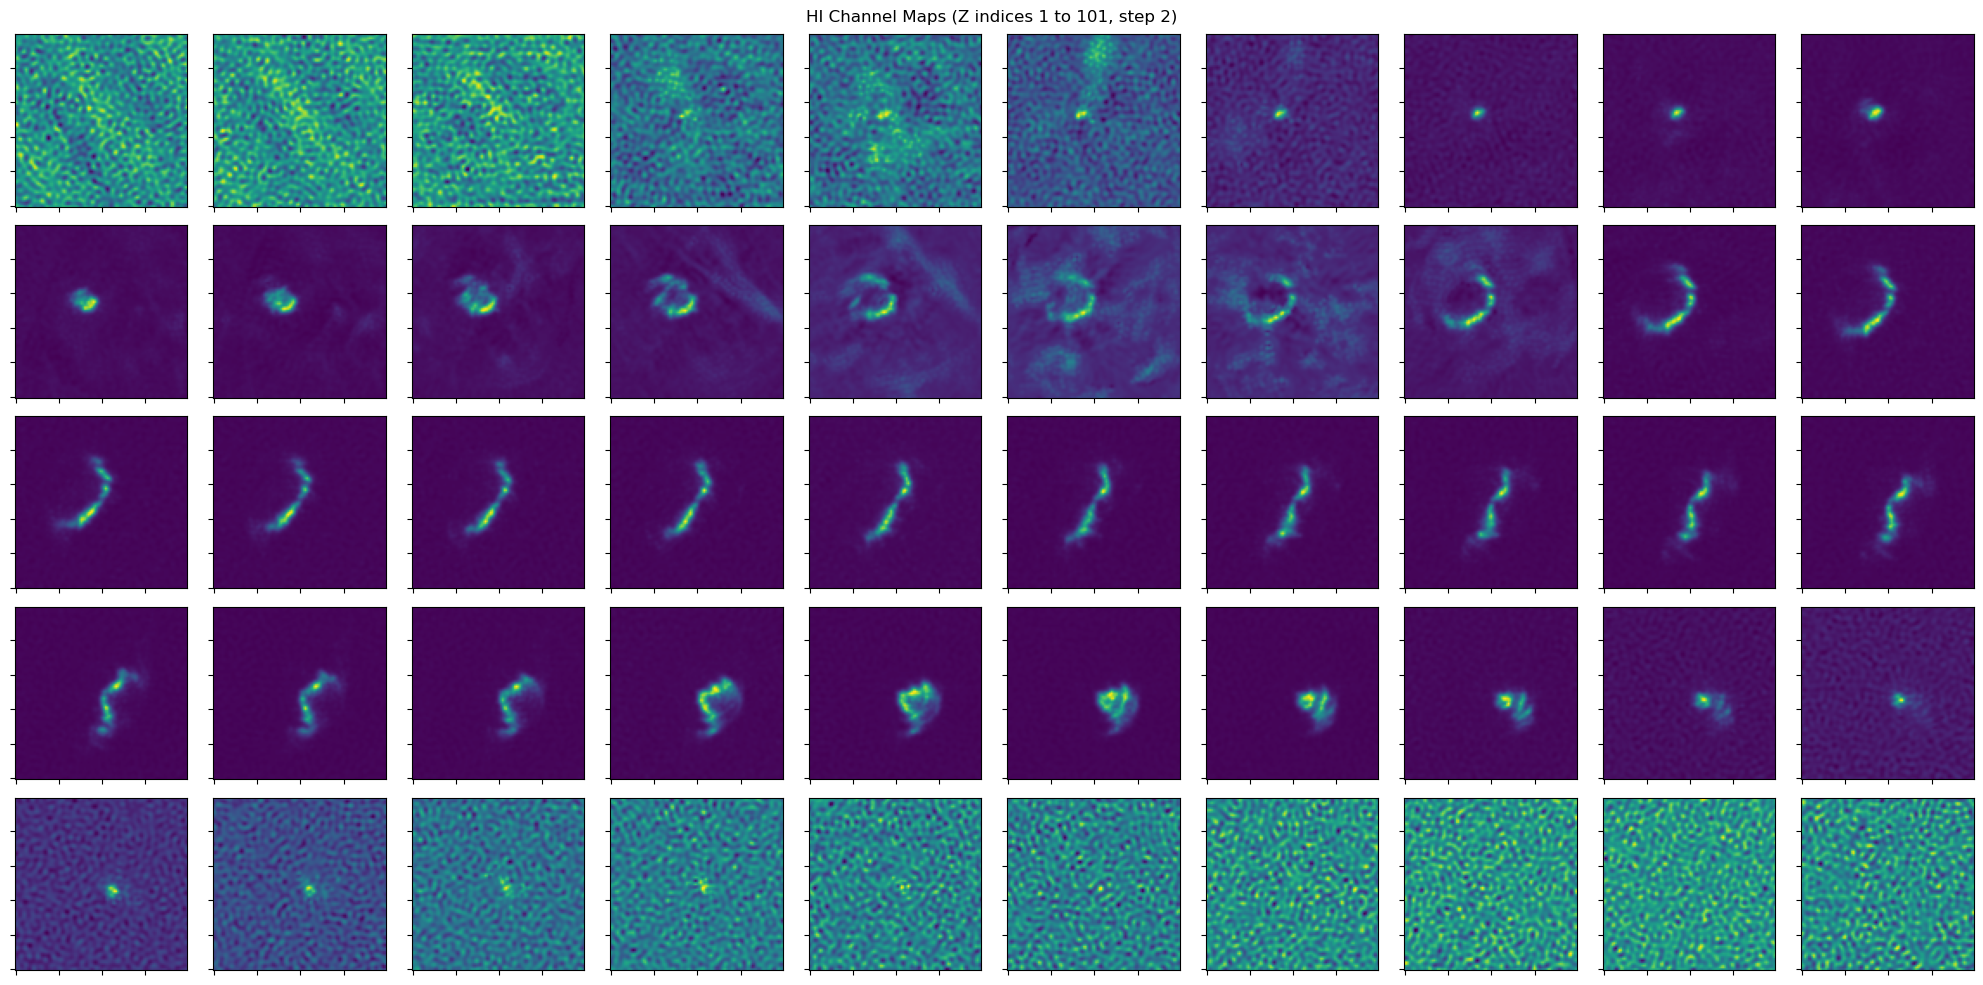

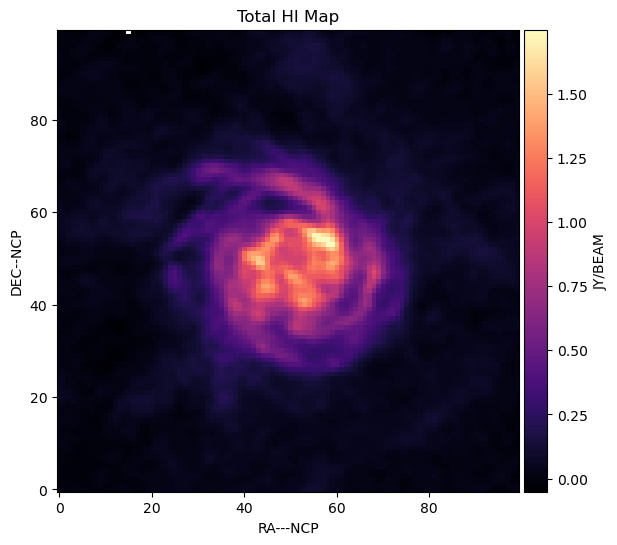

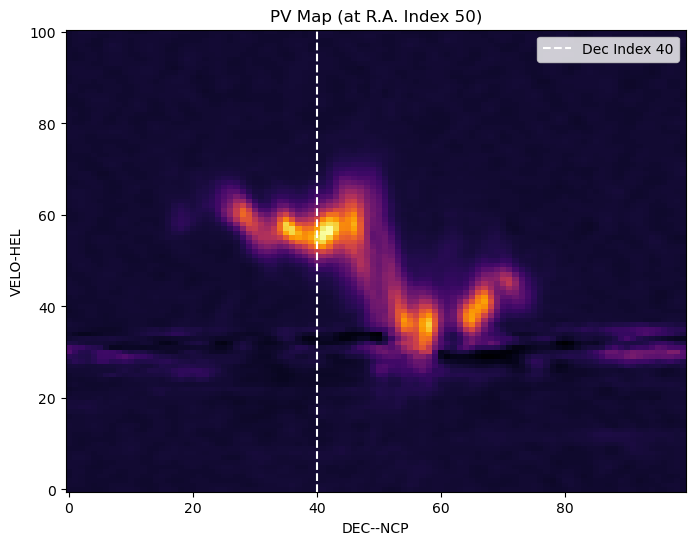

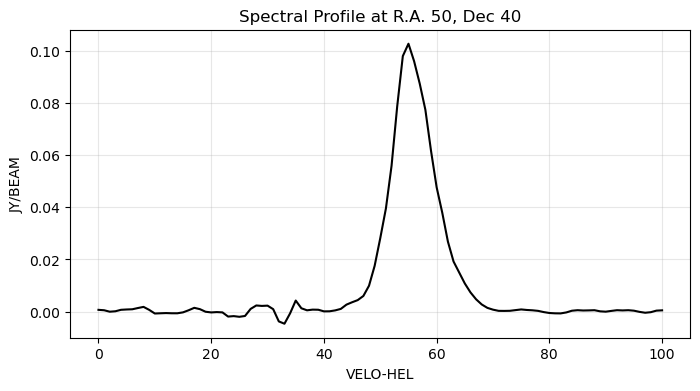

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Load Data
hdul = fits.open("ngc6946.fits")
header = hdul[0].header
data = hdul[0].data  # Shape: (Channels, Dec, RA)

# Get header labels
ctype1 = header.get('CTYPE1', 'Right Ascension')
ctype2 = header.get('CTYPE2', 'Declination')
ctype3 = header.get('CTYPE3', 'Velocity')
bunit = header.get('BUNIT', 'Intensity')

# --- 2. Channel Map Mosaic ---
indices = range(1, 101, 2)
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
fig.suptitle("HI Channel Maps (Z indices 1 to 101, step 2)")

for i, ax in enumerate(axes.flat):
    if i < len(indices):
        ax.imshow(data[indices[i]], origin='lower', cmap='viridis')
        # Remove axis labeling as requested
        ax.set_xticklabels([])
        ax.set_yticklabels([])
plt.tight_layout()
plt.show()

# --- 3. Total HI Map ---
# Summing over the velocity axis (axis 0)
# Note: In a real scenario, you'd select a range [start:end] to avoid noise
total_hi = np.sum(data[20:80], axis=0) 

plt.figure(figsize=(8, 6))
im = plt.imshow(total_hi, origin='lower', cmap='magma')
plt.xlabel(ctype1)
plt.ylabel(ctype2)
plt.title("Total HI Map")

# Locatable colorbar
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax, label=bunit)
plt.show()

# --- 4. Position-Velocity (PV) Map ---
# Fixed R.A. (X-axis) with index 50 -> Slice along Dec (Y) and Velocity (Z)
pv_map = data[:, :, 50] 

plt.figure(figsize=(8, 6))
plt.imshow(pv_map, origin='lower', aspect='auto', cmap='inferno')
plt.axvline(x=40, color='white', linestyle='--', label='Dec Index 40') # Vertical line at Dec 40
plt.xlabel(ctype2) # Declination
plt.ylabel(ctype3) # Velocity/Frequency
plt.title("PV Map (at R.A. Index 50)")
plt.legend()
plt.show()

# --- 5. Global HI Spectral Profile ---
# Slice at fixed R.A. (50) and Dec (40) across all Z indices
spectral_profile = data[:, 40, 50]

plt.figure(figsize=(8, 4))
plt.plot(spectral_profile, color='black')
plt.xlabel(ctype3)
plt.ylabel(bunit)
plt.title(f"Spectral Profile at R.A. 50, Dec 40")
plt.grid(True, alpha=0.3)
plt.show()

hdul.close()